# Portfolio Project: Marketing Attribution & Campaign Analytics
## Notebook 04: Channel Effectiveness & Campaign Strategy Analysis

**Role:** Data Analyst  
**Prepared by:** Akshansh Vijay  
**Objective:** Evaluate marketing channel efficiency and compare campaign strategies (Paid Ads, Email, SEO, Influencer, Social Media) to determine the most cost-effective customer acquisition funnels.

### 1. Load Preprocessed Clean Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Resolve path
data_dir = 'data'
if not os.path.exists(data_dir):
    data_dir = os.path.join('..', 'data')

# Load clean data
marketing = pd.read_csv(os.path.join(data_dir, 'marketing_data_cleaned.csv'))

### 2. Channel Performance & Ranking Analysis
We analyze marketing channels and multi-channel configurations. We select the top 10 channels for clear visual analysis on horizontal bar charts.

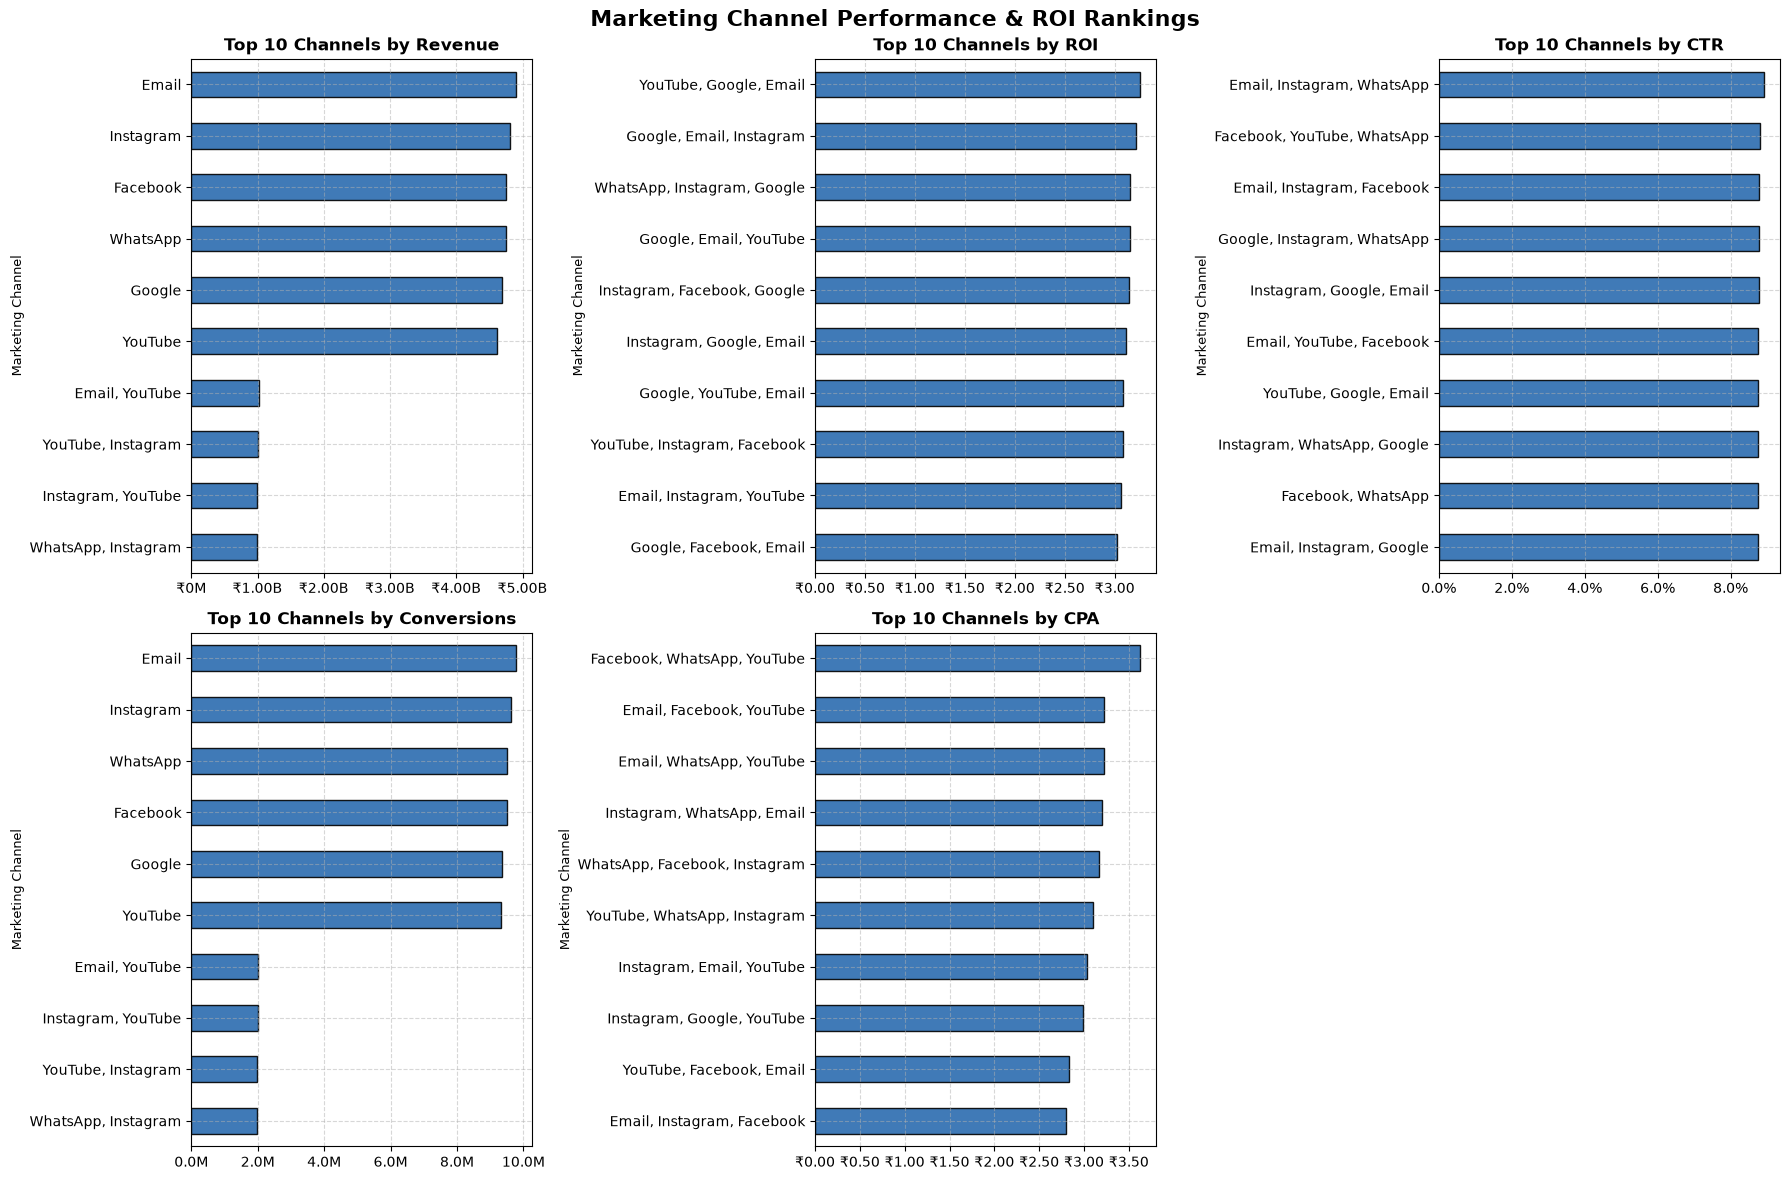

,Revenue,ROI,CTR,Conversions,CPA
Channel_Used,,,,,
Email,4903318280,2.761475,8.549900,9782981,2.058295
Instagram,4806483195,2.688871,8.545670,9640461,2.074206
Facebook,4747180826,2.675875,8.462548,9493444,2.034721
WhatsApp,4744417146,2.736249,8.497838,9512537,2.187012
Google,4683310624,2.642019,8.500840,9365711,2.089157
YouTube,4620936978,2.564019,8.437274,9323440,2.238410
"Email, YouTube",1024605964,2.848552,8.523153,2020744,1.799580
"YouTube, Instagram",999704352,2.719447,8.593015,1982344,1.941678
"Instagram, YouTube",998145236,2.896699,8.559532,2017287,1.686312


In [2]:
# Channel stats
channel_stats = marketing.groupby('Channel_Used').agg({
    'Revenue': 'sum',
    'ROI': 'mean',
    'CTR': 'mean',
    'Conversions': 'sum',
    'CPA': 'mean'
})

fig, axes = plt.subplots(2, 3, figsize=(18, 12), dpi=100)
axes = axes.flatten()
channel_metrics = ['Revenue', 'ROI', 'CTR', 'Conversions', 'CPA']

for i, metric in enumerate(channel_metrics):
    ax = axes[i]
    # Top 10 channels
    top_channels = channel_stats.sort_values(metric, ascending=True).tail(10)
    top_channels[metric].plot(kind='barh', ax=ax, color='#2b6cb0', edgecolor='black', alpha=0.9)
    ax.set_title(f'Top 10 Channels by {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Marketing Channel', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Format axes
    if metric == 'Revenue':
        ax.xaxis.set_major_formatter(lambda x, pos: f'₹{x*1e-6:.0f}M' if x < 1e9 else f'₹{x*1e-9:.2f}B')
    elif metric == 'Conversions':
        ax.xaxis.set_major_formatter(lambda x, pos: f'{x*1e-6:.1f}M')
    elif metric == 'CTR':
        ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.1f}%')
    elif metric in ['CPA', 'ROI']:
        ax.xaxis.set_major_formatter(lambda x, pos: f'₹{x:.2f}' if metric=='CPA' else f'{x:.2f}x')

axes[5].axis('off')
plt.suptitle('Marketing Channel Performance & ROI Rankings', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Print Top 10 by Revenue
channel_stats.sort_values('Revenue', ascending=False).head(10)

### Channel Performance - Business Interpretation & Budget Recommendations
- **Top Revenue Channels:** **Email** leads with **₹4.90B** in revenue (ROI: **2.76x**, CPA: **₹2.06**), followed closely by **Instagram** at **₹4.81B**.
- **Omnichannel Synergy:** Multi-channel touchpoints demonstrate strong efficiency. For instance, **Instagram, YouTube** campaigns achieve an Average ROI of **2.90x**, and **Email, YouTube** campaigns yield **2.85x**.
- **Budget Shift:** Reduce spend on standalone **YouTube** campaigns (lowest single channel ROI at **2.56x** and highest CPA at **₹2.24**) and redirect funds into **multichannel combinations** (e.g. Instagram + YouTube and Email + YouTube) to capture higher conversion rates.

### 3. Campaign Type Analysis
We analyze campaign categories: **Email**, **Influencer**, **Paid Ads**, **SEO**, and **Social Media**.

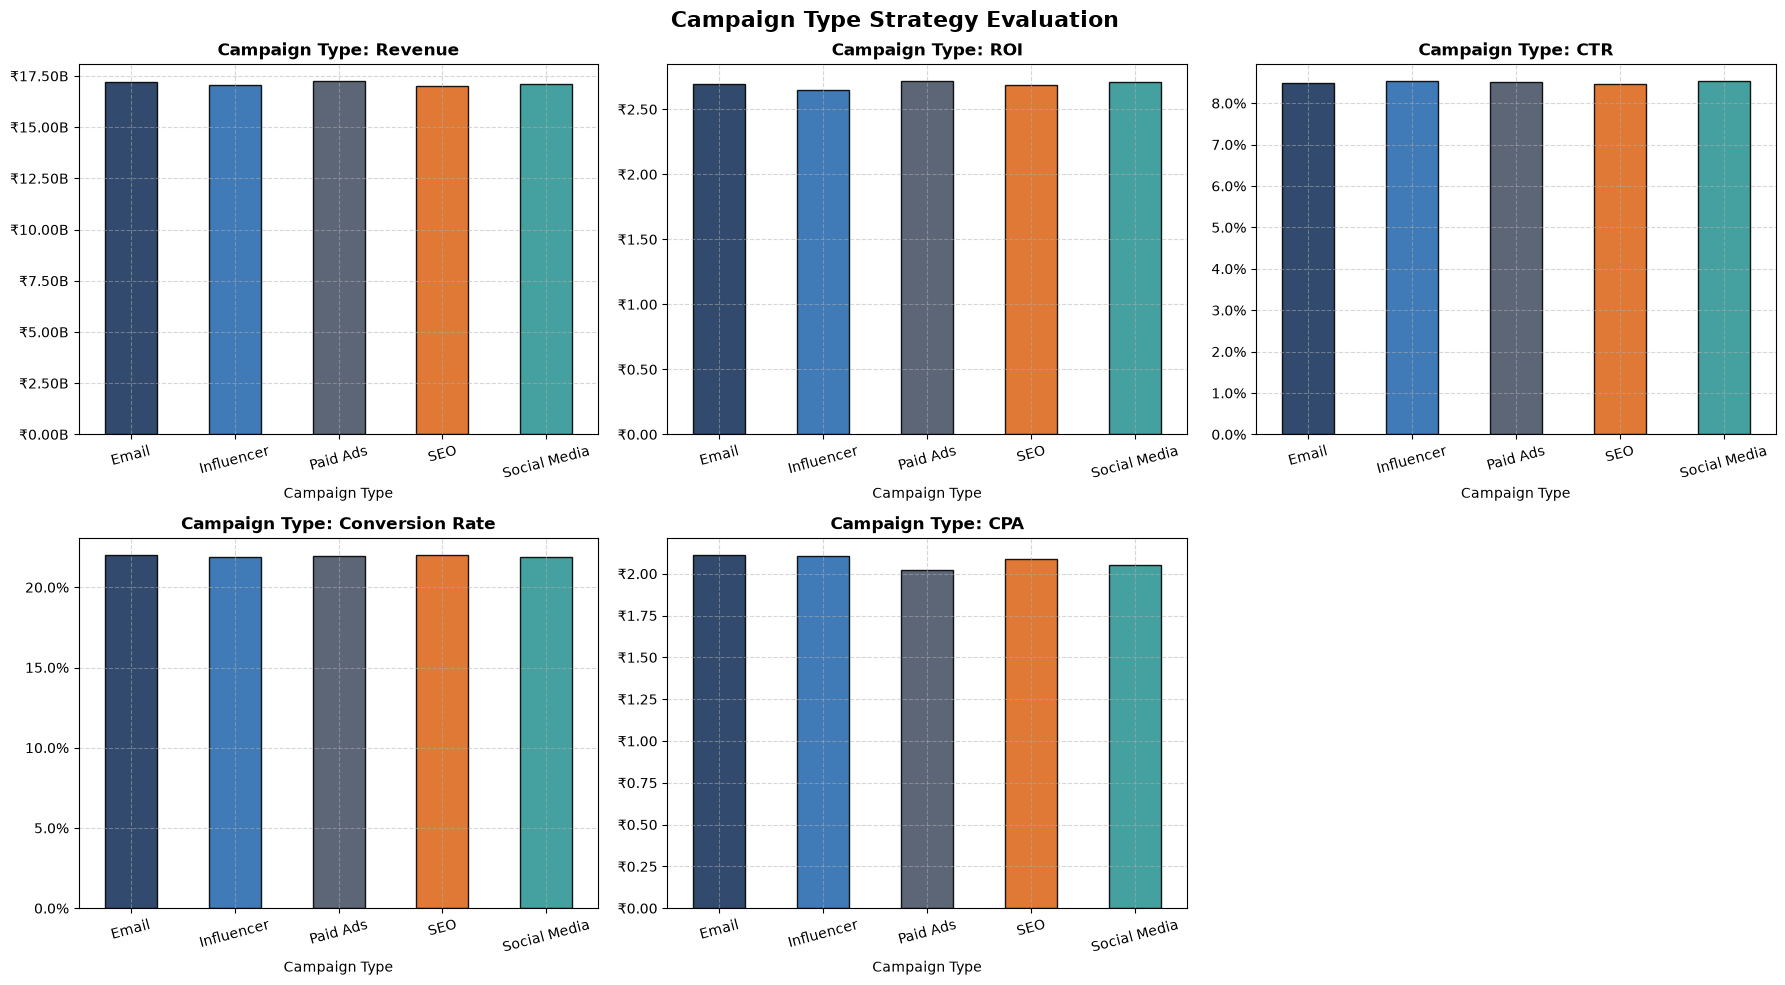

,Revenue,ROI,CTR,Conversion_Rate,CPA
Campaign_Type,,,,,
Email,17222575561,2.693300,8.482087,22.000691,2.111047
Influencer,17080750747,2.648540,8.525260,21.907962,2.104761
Paid Ads,17238518867,2.714927,8.510288,21.948226,2.024412
SEO,17005702921,2.688255,8.466248,21.996483,2.086327
Social Media,17102697975,2.708121,8.527726,21.873276,2.053936


In [3]:
# Campaign stats
camp_stats = marketing.groupby('Campaign_Type').agg({
    'Revenue': 'sum',
    'ROI': 'mean',
    'CTR': 'mean',
    'Conversion_Rate': 'mean',
    'CPA': 'mean'
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=100)
axes = axes.flatten()
colors = ['#1a365d', '#2b6cb0', '#4a5568', '#dd6b20', '#319795']

camp_metrics = ['Revenue', 'ROI', 'CTR', 'Conversion_Rate', 'CPA']
for i, metric in enumerate(camp_metrics):
    ax = axes[i]
    camp_stats[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.9)
    ax.set_title(f'Campaign Type: {metric.replace("_", " ")}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Campaign Type', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Format axes
    if metric == 'Revenue':
        ax.yaxis.set_major_formatter(lambda x, pos: f'₹{x*1e-9:.2f}B')
    elif metric in ['CTR', 'Conversion_Rate']:
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1f}%')
    elif metric in ['CPA', 'ROI']:
        ax.yaxis.set_major_formatter(lambda x, pos: f'₹{x:.2f}' if metric=='CPA' else f'{x:.2f}x')

axes[5].axis('off')
plt.suptitle('Campaign Type Strategy Evaluation', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

camp_stats

### Campaign Type Performance - Business Interpretation
- **Paid Ads Leads:** **Paid Ads** generated the highest overall revenue (**₹17.24B**) and the highest average ROI (**2.71x**), while maintaining the lowest average CPA (**₹2.02**).
- **SEO Performance:** **SEO** campaigns generate the lowest absolute revenue (**₹17.01B**), showing limited scalability in driving rapid sales cycles despite a solid conversion rate.